In [1]:
# -*- coding: utf-8 -*-
"""
Created on Sat Feb  7 18:58:42 2026

@author: MSI
"""
import numpy as np
import matplotlib.pyplot as plt

#Definimos las funciones que vamos a usar

#Función sección eficaz:
def crossection(Earray,M,Tth,Qw):
    
    K=4.215e-45*(Qw**2)*M
    
    Tmax= Earray/(1+(M/(2*Earray)))
    
    sigma = K * ( (Tmax - Tth) - ((1/(2*Earray)) + (M/(4*Earray**2))) * (Tmax**2 - Tth**2) + (1/(6*Earray**2)) * (Tmax**3 - Tth**3) )
    
    return sigma

#Función probabilidad de oscilación en el vacío
def probvac(theta_v,mass_21,L,E):
    
    L_columna = L[:, np.newaxis]
    
    P=(np.sin(2*theta_v)**2)*(np.sin(1.267*mass_21*L_columna/(E)))**2
    
    return P

#Función probabilidad para densidad de materia constante
def probmatcte(theta_v,mass_21,L,E):
    
    rho=150 #Densidad de la materia en g/cm^3
    
    Ye=0.5 #Fracción de electrones
    
    A=1.52e-4*Ye*rho*E #2*sqrt(2)*GF*Ne*E
    
    
    mattert=np.sqrt(((np.sin(2*theta_v)**2)+(np.cos(2*theta_v)-A/(mass_21**2))**2))
    
    L_columna = L[:, np.newaxis]
    
    sinmatt2=(np.sin(2*theta_v)**2)/(mattert**2)
    
    mass_matt2= mattert*(mass_21**2)
    
    P=(sinmatt2)*(np.sin(1.267*mass_matt2*L_columna/(E)))**2
    
    return P

#Función probabilidad para densidad de materia variable en el sol
def probmatvarsol(theta_v,mass_21,L,E):
    
    L_columna = L[:, np.newaxis]

    Rsol=695700#Radio del sol normalizado en L para que recorra todo el sol en mi array
    
    rho=245*np.exp(-10.54*L_columna/Rsol) #Densidad de la materia en g/cm^3
    
    Ye=0.5 #Fracción de electrones
    
    A=1.52e-4*Ye*rho*E #2*sqrt(2)*GF*Ne*E
    
    
    #mattert=np.sqrt(((np.sin(2*theta_v)**2)+(np.cos(2*theta_v)-A/(mass_21**2))**2))
    
    
    #mass_matt2= mattert*(mass_21**2)
    
    #Cálculo del cos(2theta_m)
    contiguo=mass_21*np.cos(2*theta_v)-A
    
    opuesto=mass_21*np.sin(2*theta_v)
    
    cosmatt2=contiguo/(np.sqrt(contiguo**2+opuesto**2))
    
    
    #Cálculo de crossing probability  y los factores gamma
    
    r_0=Rsol/10.54
    
    gammatilde=5.068*np.pi*r_0*mass_21/E #Calculamos gammatilde
    
    gamma=gammatilde*np.sin(theta_v)**2/(2*np.pi*np.cos(2*theta_v))#Calculamos gamma para mostrarlo en pantalla
    
    Pc=np.zeros(len(E))

#Para cada energía del array de energías, calculamos un Pc diferente

    for i in range(len(E)):
        
        if gammatilde[i]<500:
            
            Pc[i]=(np.exp(gammatilde[i]*np.cos(theta_v)**2)-1)/(np.exp(gammatilde[i])-1)
            
        else:
            
            Pc[i]=0
            
    #Calculamos los senos y los cosenos del ángulo de mezcla en materia para ver los estados de materia
    
    cos=np.sqrt((1+cosmatt2)/2)
    
    sen=np.sqrt((1-cosmatt2)/2)
        
    #Cálculo de la probabilidad de oscilación para el neutrino electrónico
    P=0.5+0.5*(2*Pc-1)*cosmatt2[0]*cosmatt2
    
    #Cálculo del porcentaje que nace como v2 y v1
    
    porcentajev1=0.5 + 0.5 * cosmatt2[0]
    porcentajev2=0.5 - 0.5 * cosmatt2[0]
    
    #Calculo de la probabilidad de supervivencia para v2
    
    
    return P,cos,sen,porcentajev1,porcentajev2,Pc,gamma



In [4]:
#Introducimos los parámetros iniciales para la simulación de la sección eficaz:
    
Tth=1e-4#En MeV para un detector de germanio   

M=122.262#Masa del germanio promediada entre isótopos en MeV

N=40.6

Z=32

Qw=N-(1-4*0.238)*Z 

Emin=0.5*(np.sqrt(2*M*Tth+Tth**2)+Tth)#Energía mínima que puede alcanzar el detector

Earray=np.linspace(Emin,15,1000)#Energía del neutrino incidente en MeV

sig=crossection(Earray, M, Tth, Qw) #Llamamos a la función para hacer el cálculo


#Introducimos los parámetros iniciales para la simulación de la variación de sabor

L=np.linspace(0,1000,1000)#distancia en km

L_sol=np.linspace(0,696340,2000)

mass_21=7.53*10**(-5)#diferencia de masas en el vacío al cuadrado

theta_v=0.58733#ángulo en el vacío al cuadrado

sin2=np.sin(theta_v)**2


elotro=1-0.5*np.sin(theta_v*2)**2
print(sin2)
print(elotro)
#Energía usada en GeV
E=np.array([0.4e-3,5e-3,10e-3,15e-3,10])

#Cálculo de la probabilidad de oscilación en el vacío
P_vacio=probvac(theta_v,mass_21,L,E)

#Cálculo de la probabilidad de oscilación para densidad constante
P_cte=probmatcte(theta_v,mass_21,L,E)

#Cálculo de la probabilidad de supervivencia para densidad variable(sol)
P_var,cosmat,senmat,porcentaje_v1,porcentaje_v2,Pc,gamma=probmatvarsol(theta_v, mass_21, L_sol, E)



0.3070716170646748
0.574442721884079


Para E = 0.4 MeV:

  - Nace como v1: 0.65%

  - Nace como v2: 0.35%

 Gamma vale 25057.4

  la crossing probability es de 0.0

 y la probabilidad de supervivencia del estado de masa 2 durante el viaje es 1.00


Para E = 5.0 MeV:

  - Nace como v1: 0.16%

  - Nace como v2: 0.84%

 Gamma vale 2004.6

  la crossing probability es de 0.0

 y la probabilidad de supervivencia del estado de masa 2 durante el viaje es 1.00


Para E = 10.0 MeV:

  - Nace como v1: 0.04%

  - Nace como v2: 0.96%

 Gamma vale 1002.3

  la crossing probability es de 0.0

 y la probabilidad de supervivencia del estado de masa 2 durante el viaje es 1.00


Para E = 15.0 MeV:

  - Nace como v1: 0.02%

  - Nace como v2: 0.98%

 Gamma vale 668.2

  la crossing probability es de 0.0

 y la probabilidad de supervivencia del estado de masa 2 durante el viaje es 1.00


Para E = 10000.0 MeV:

  - Nace como v1: 0.00%

  - Nace como v2: 1.00%

 Gamma vale 1.0

  la crossing probability es de 0.08770495267533383

 y la probabili

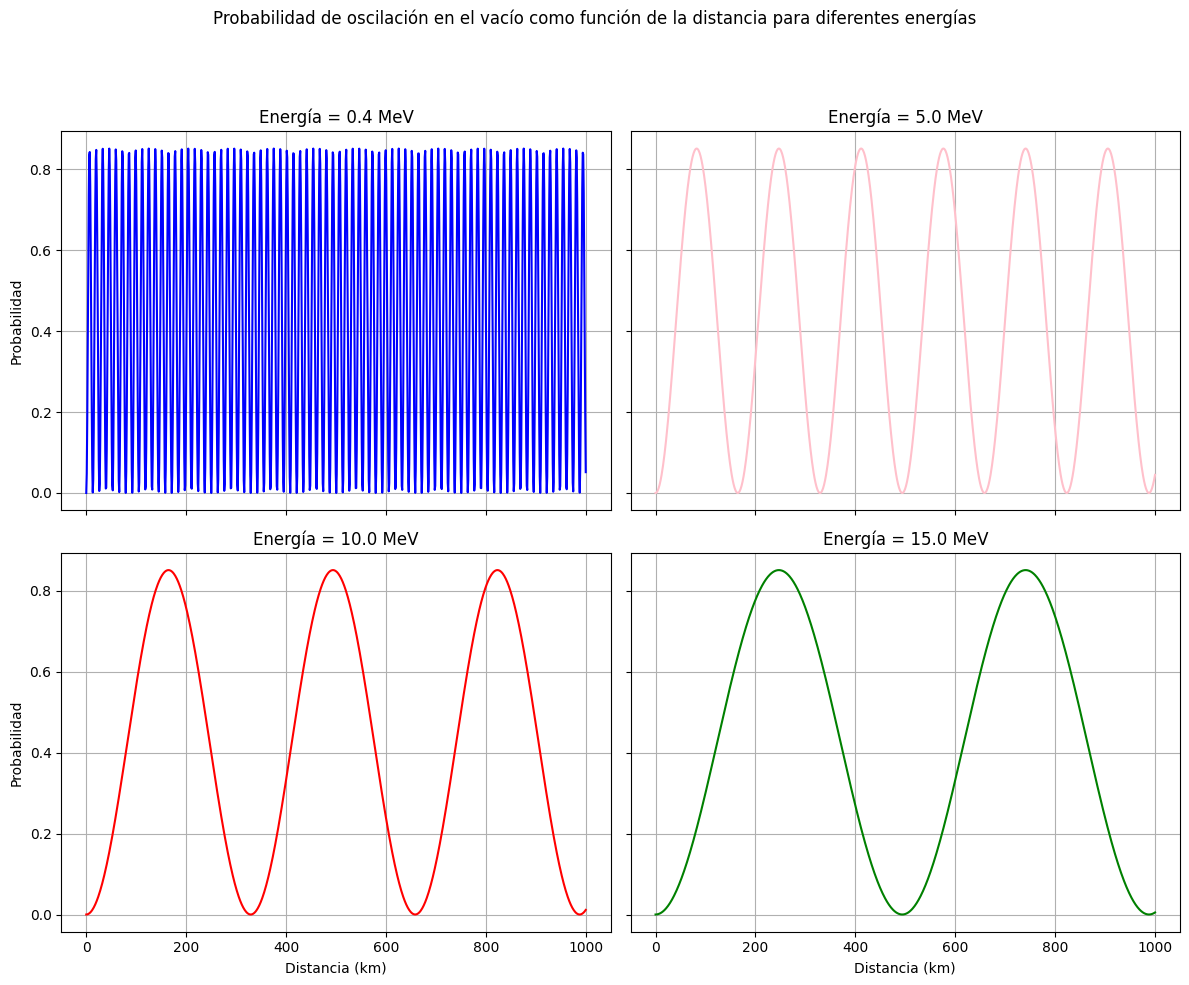

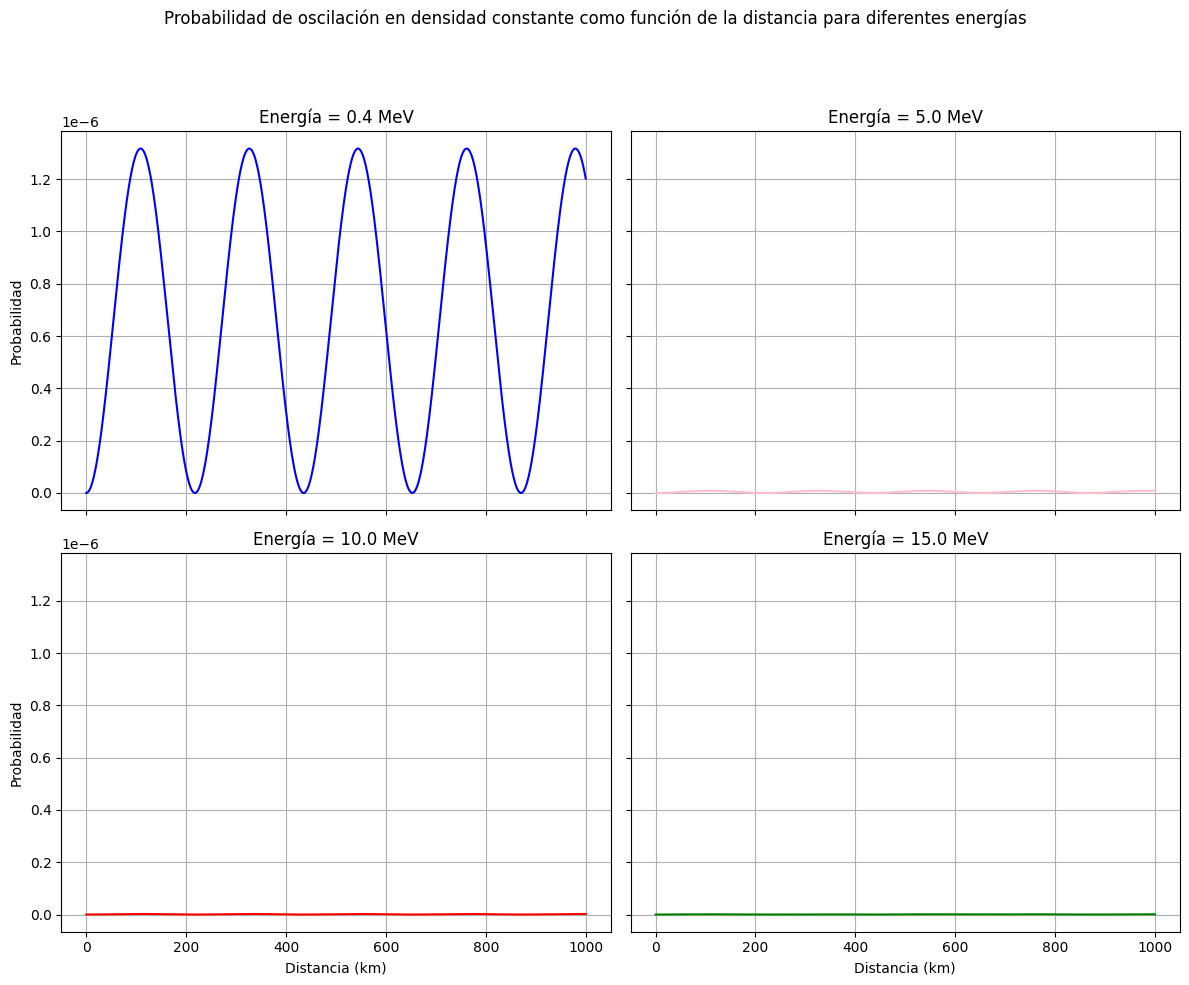

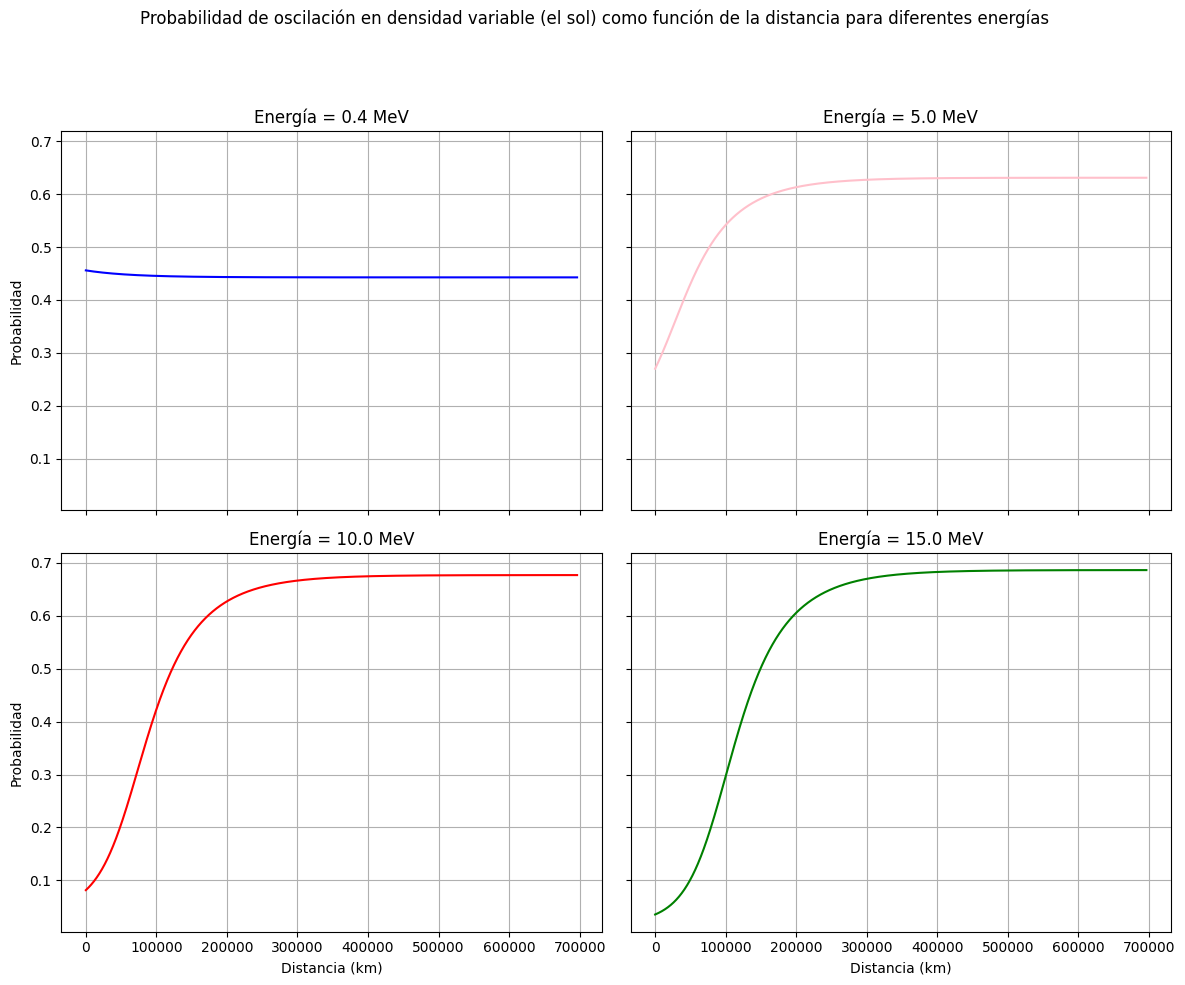

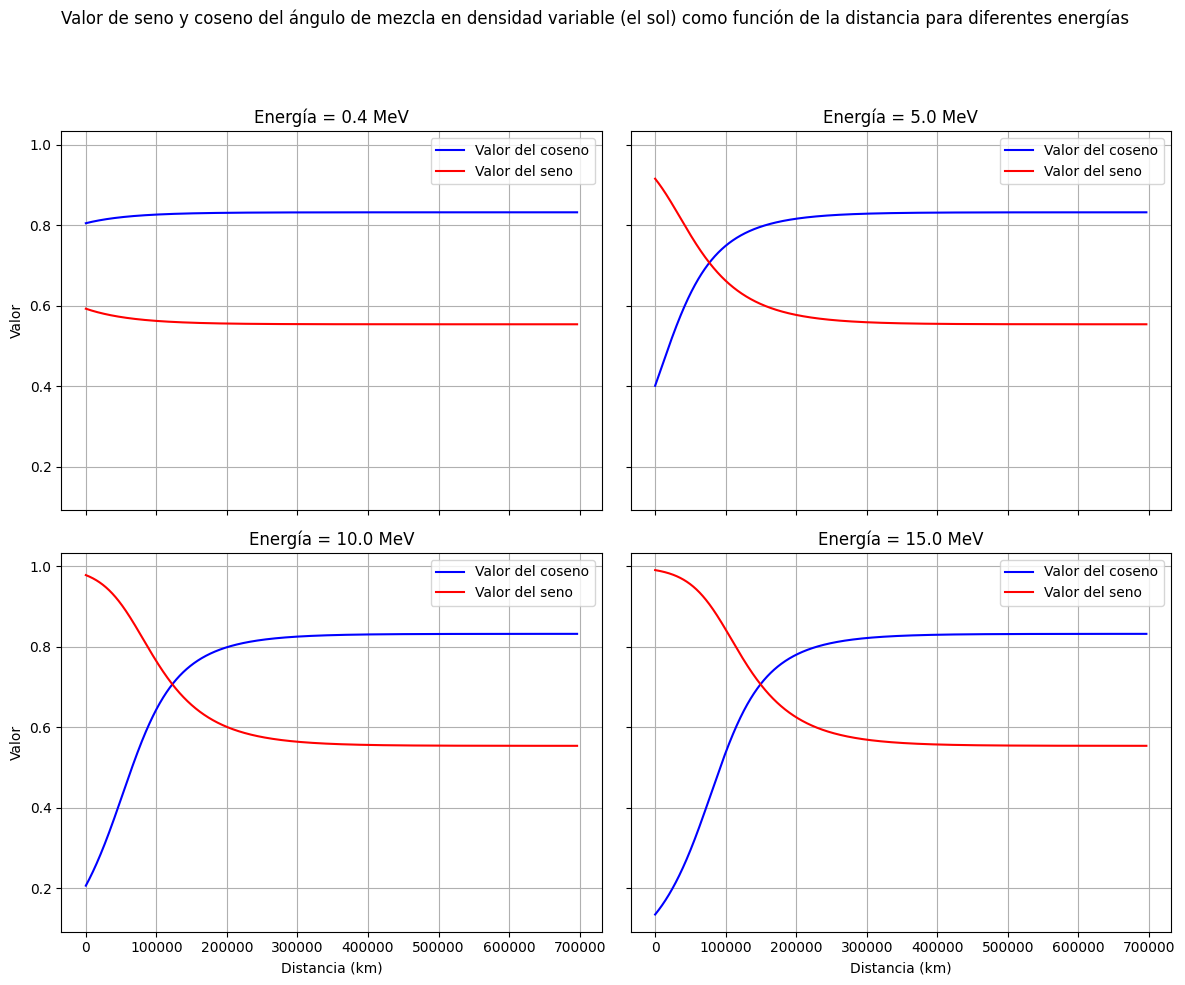

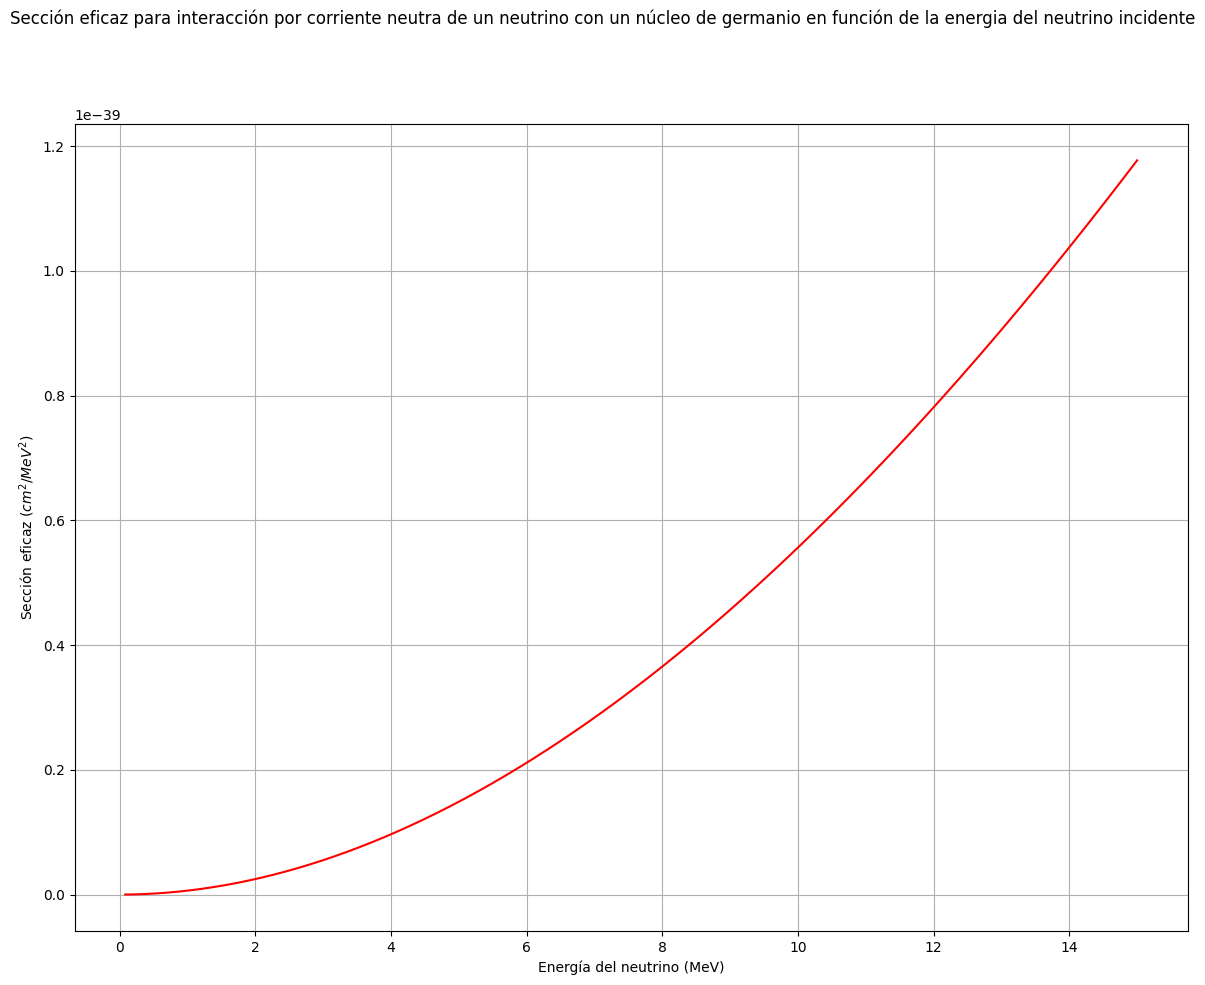

In [ ]:
#Printeamos la probabilidad de supervivencia para el v2 y su ratio de aparición
for i in range(len(E)):
    print(f"Para E = {E[i] * 1e3:.1f} MeV:\n")
    print(f"  - Nace como v1: {porcentaje_v1[i]:.2f}%\n")
    print(f"  - Nace como v2: {porcentaje_v2[i]:.2f}%\n")
    print(f" Gamma vale {gamma[i]:.1f}\n")
    print(f"  la crossing probability es de {Pc[i]}\n")
    print(f" y la probabilidad de supervivencia del estado de masa 2 durante el viaje es {1-Pc[i]:.2f}\n\n")
#Definimos las figuras
fig1, ax1 =plt.subplots(2, 2, figsize=(12,10),sharex=True, sharey=True)

fig2, ax2 =plt.subplots(2, 2, figsize=(12,10),sharex=True, sharey=True)

fig3, ax3 =plt.subplots(2, 2, figsize=(12,10),sharex=True, sharey=True)

fig4, ax4 =plt.subplots(2, 2, figsize=(12,10),sharex=True, sharey=True)

fig5, ax5 =plt.subplots(1, 1, figsize=(12,10))

#Figura arriba izquierda en el vacío
ax1[0, 0].plot(L, P_vacio[:, 0], color='blue')
ax1[0, 0].set_title(f"Energía = {E[0]*10**3} MeV")
ax1[0, 0].grid(True)

#Figura arriba izquierda en densidad constante
ax2[0, 0].plot(L, P_cte[:, 0], color='blue')
ax2[0, 0].set_title(f"Energía = {E[0]*10**3} MeV")
ax2[0, 0].grid(True)

#Figura arriba izquierda en densidad variable
ax3[0, 0].plot(L_sol, P_var[:, 0], color='blue')
ax3[0, 0].set_title(f"Energía = {E[0]*10**3} MeV")
#ax3[0, 0].plot(L_sol, sin2, color='pink')
#ax3[0, 0].plot(L_sol, elotro, color='black')
ax3[0, 0].grid(True)

#Figura arriba izquierda para coseno y seno en densidad variable
ax4[0, 0].plot(L_sol, cosmat[:, 0], color='blue',label='Valor del coseno')
ax4[0, 0].plot(L_sol, senmat[:, 0], color='red', label='Valor del seno')
ax4[0, 0].set_title(f"Energía = {E[0]*10**3} MeV")
ax4[0, 0].grid(True)
ax4[0, 0].legend()

#Figura arriba derecha en el vacío
ax1[0, 1].plot(L, P_vacio[:, 1], color='pink')
ax1[0, 1].set_title(f"Energía = {E[1]*10**3} MeV")
ax1[0, 1].grid(True)

#Figura arriba derecha en densidad constante
ax2[0, 1].plot(L, P_cte[:, 1], color='pink')
ax2[0, 1].set_title(f"Energía = {E[1]*10**3} MeV")
ax2[0, 1].grid(True)

#Figura arriba derecha en densidad constante
ax3[0, 1].plot(L_sol, P_var[:, 1], color='pink')
#ax3[0, 1].plot(L_sol, sin2, color='pink')
#ax3[0, 1].plot(L_sol, elotro, color='black')
ax3[0, 1].set_title(f"Energía = {E[1]*10**3} MeV")
ax3[0, 1].grid(True)

#Figura arriba derecha para coseno y seno en densidad variable
ax4[0, 1].plot(L_sol, cosmat[:, 1], color='blue',label='Valor del coseno')
ax4[0, 1].plot(L_sol, senmat[:, 1], color='red', label='Valor del seno')
ax4[0, 1].set_title(f"Energía = {E[1]*10**3} MeV")
ax4[0, 1].grid(True)
ax4[0, 1].legend()

#Figura abajo izquierda en el vacío
ax1[1, 0].plot(L, P_vacio[:, 2], color='red')
ax1[1, 0].set_title(f"Energía = {E[2]*10**3} MeV")
ax1[1, 0].grid(True)

#Figura abajo izquierda en densidad constante
ax2[1, 0].plot(L, P_cte[:, 2], color='red')
ax2[1, 0].set_title(f"Energía = {E[2]*10**3} MeV")
ax2[1, 0].grid(True)

#Figura abajo izquierda en densidad variable
ax3[1, 0].plot(L_sol, P_var[:, 2], color='red')
ax3[1, 0].set_title(f"Energía = {E[2]*10**3} MeV")
#ax3[1, 0].plot(L_sol, sin2, color='pink')
#ax3[1, 0].plot(L_sol, elotro, color='balck')
ax3[1, 0].grid(True)

#Figura abajo izquierda para coseno y seno en densidad variable
ax4[1, 0].plot(L_sol, cosmat[:, 2], color='blue',label='Valor del coseno')
ax4[1, 0].plot(L_sol, senmat[:, 2], color='red', label='Valor del seno')
ax4[1, 0].set_title(f"Energía = {E[2]*10**3} MeV")
ax4[1, 0].grid(True)
ax4[1, 0].legend()

#Figura abajo derecha en el vacío
ax1[1, 1].plot(L, P_vacio[:, 3], color='green')
ax1[1, 1].set_title(f"Energía = {E[3]*10**3} MeV")
ax1[1, 1].grid(True)

#Figura abajo derecha en densidad constante
ax2[1, 1].plot(L, P_cte[:, 3], color='green')
ax2[1, 1].set_title(f"Energía = {E[3]*10**3} MeV")
ax2[1, 1].grid(True)

#Figura abajo derecha en densidad variable
ax3[1, 1].plot(L_sol, P_var[:, 3], color='green')
ax3[1, 1].set_title(f"Energía = {E[3]*10**3} MeV")
#ax3[1, 1].plot(L_sol, sin2, color='pink')
#ax3[1, 1].plot(L_sol, elotro, color='black')
ax3[1, 1].grid(True)

#Figura abajo derecha para coseno y seno en densidad variable
ax4[1, 1].plot(L_sol, cosmat[:, 3], color='blue',label='Valor del coseno')
ax4[1, 1].plot(L_sol, senmat[:, 3], color='red', label='Valor del seno')
ax4[1, 1].set_title(f"Energía = {E[3]*10**3} MeV")
ax4[1, 1].grid(True)
ax4[1, 1].legend()

#Figura sección eficaz:
ax5.plot(Earray,sig,color='red')
ax5.grid(True)


#Ajustamos el eje y en el vacío
ax1[0, 0].set_ylabel("Probabilidad")
ax1[1, 0].set_ylabel("Probabilidad")

#Ajustamos el eje y en densidad constante
ax2[0, 0].set_ylabel("Probabilidad")
ax2[1, 0].set_ylabel("Probabilidad")

#Ajustamos el eje y en densidad variable
ax3[0, 0].set_ylabel("Probabilidad")
ax3[1, 0].set_ylabel("Probabilidad")

#Ajustamos el eje y en senos y cosenos
ax4[0, 0].set_ylabel("Valor")
ax4[1, 0].set_ylabel("Valor")

#Ajustamos el eje y en la sección eficaz
ax5.set_ylabel("Sección eficaz ($cm^2/MeV^2$)")

#Ajustamos el eje x en el vacío
ax1[1, 0].set_xlabel("Distancia (km)")
ax1[1, 1].set_xlabel("Distancia (km)")

#Ajustamos el eje x en densidad constante
ax2[1, 0].set_xlabel("Distancia (km)")
ax2[1, 1].set_xlabel("Distancia (km)")

#Ajustamos el eje x en densidad variable
ax3[1, 0].set_xlabel("Distancia (km)")
ax3[1, 1].set_xlabel("Distancia (km)")

#Ajustamos el eje x en senos y cosenos
ax4[1, 0].set_xlabel("Distancia (km)")
ax4[1, 1].set_xlabel("Distancia (km)")

#Ajustamos el eje x en la sección eficaz
ax5.set_xlabel("Energía del neutrino (MeV)")


#Ajustamos el título del plot en el vacío
fig1.suptitle('Probabilidad de oscilación en el vacío como función de la distancia para diferentes energías')
fig1.tight_layout(rect=[0, 0, 1, 0.93])


#Ajustamos el título del plot en densidad constante
fig2.suptitle('Probabilidad de oscilación en densidad constante como función de la distancia para diferentes energías')
fig2.tight_layout(rect=[0, 0, 1, 0.93])

#Ajustamos el título del plot en densidad variable
fig3.suptitle('Probabilidad de oscilación en densidad variable (el sol) como función de la distancia para diferentes energías')
fig3.tight_layout(rect=[0, 0, 1, 0.93])

#Ajustamos el título del plot en senos y cosenos
fig4.suptitle('Valor de seno y coseno del ángulo de mezcla en densidad variable (el sol) como función de la distancia para diferentes energías')
fig4.tight_layout(rect=[0, 0, 1, 0.93])

#Ajustamos el título del plot en la sección eficaz
fig5.suptitle('Sección eficaz para interacción por corriente neutra de un neutrino con un núcleo de Xenon en función de la energia del neutrino incidente')
fig5.tight_layout(rect=[0, 0, 1, 0.93])

#Mostramos
plt.show()
